In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sc
import sklearn as sk

#TODO
#Encoder
#Comments / type adnotation

In [ ]:
"""Assuming that the imput are lables """


def gini_impurity(lables: np.array) -> float:
    if lables.size == 0: return 0.0

    _, counts = np.unique(lables, return_counts=True)
    p = counts / counts.sum()
    return 1.0-sum(p**2)

def entropy(lables: np.array) -> float:
    if lables.size == 0: return 0.0
    
    _, counts = np.unique(lables, return_counts=True)
    p = counts / counts.sum()
    p = p[p > 0]
    return np.sum(p*np.log2(p))

def weighted_impurity(left: np.array, right: np.array) -> float:
    n_left, n_right = len(left), len(right)
    total = n_left + n_right
    if total == 0: return 0
    g_left = gini_impurity(left)
    g_right = gini_impurity(right)
    return (n_left / total) * g_left + (n_right / total) * g_right

def info_gain(parent:np.array, left: np.array, right: np.array) ->float:
    n = len(parent)
    if n == 0: return 0.0
    n_left = len(left)
    n_right = len(right)

    H_parent = entropy(parent)
    H_left = entropy(left)
    H_right = entropy(right)

    return H_parent - ((n_left / n) * H_left +(n_right / n) * H_right)

In [ ]:
import numpy as np
import heapq


class Node:
    def __init__(self, instances, prediction):
        self.is_leaf = True 
        self.instances = instances # Indices of data points in the node 
        self.prediction = prediction 

    def split(self, feature, threshold, left, right):
        self.is_leaf = False  # Becomes a decision node
        self.feature = feature  # Splitting feature
        self.threshold = threshold  # Threshold value for splitting
        self.left = left  
        self.right = right  

class DecisionTree:
    def __init__(self, criterion='gini', max_depth=None, min_to_split=2, min_samples_leaf = 1, max_leaves=None, min_impurity_decrease = 0.0):
        self._max_depth = max_depth
        self._min_to_split = min_to_split
        self._max_leaves = max_leaves
        self._min_impurity_decrease = min_impurity_decrease
        self._min_samples_leaf = min_samples_leaf
        if criterion == 'gini': self._criterion = self._gini_impurity
        if criterion == 'entropy': self._criterion = self._entropy 
        self.is_fitted = False

        #throw error if criterion is still None

    def fit(self, X, y):

        if np.issubdtype(y.dtype, np.number):
            self._is_regression = True
            self._criterion = self._mse
        else:
            self._is_regression = False

        if not self._is_regression:
            self.classes_ = np.unique(y)

        self._data = X
        self._labels = y
        #arange to get all the ids of the data for the root node
        self._root = self._make_leaf(np.arange(len(self._data)))
        if self._max_leaves is None:
            self._recursive_split(self._root, 0)
        else:
            self._closed_split()
        self.is_fitted = True
        return self

    def _find_best_split(self, node):

        instances = node.instances
        X = self._data
        y = self._labels
        total = len(y)
        n_samples = len(instances)
        n_features = X.shape[1]

        parent_impurity = self._criterion(instances)
        best_decrease = -np.inf
        best_feature = None
        best_threshold =None
        best_left = None
        best_right = None

        if isinstance(self._min_samples_leaf, float):
            if not (0 < self._min_samples_leaf <= 1):
                raise ValueError("min_samples_leaf as float must be in (0, 1]")
            min_leaf = int(np.ceil(self._min_samples_leaf * total))

        else:
            min_leaf = self._min_samples_leaf

        for feature in range(n_features):

            sorted_idx = instances[np.argsort(X[instances, feature])]
            X_sorted = X[sorted_idx, feature]

            for i in range(1, n_samples):

                left = sorted_idx[:i]
                right = sorted_idx[i:]

                if i < min_leaf or (n_samples - i) < min_leaf: continue

                if X_sorted[i] == X_sorted[i - 1]:continue

                #midpoint at the start
                threshold = (X_sorted[i] + X_sorted[i - 1]) / 2.0

                n_left = i
                n_right = n_samples - i

                left_imp = self._criterion(left)
                right_imp = self._criterion(right)

                weighted = (n_left / n_samples) * left_imp + (n_right / n_samples) * right_imp

                decrease = parent_impurity - weighted

                if (decrease > best_decrease or
                (decrease == best_decrease and feature < best_feature) or
                (decrease == best_decrease and feature == best_feature and threshold < best_threshold)):
                    
                    best_decrease = decrease
                    best_feature = feature
                    best_threshold = threshold
                    best_left = left
                    best_right = right

                if best_feature is None or best_decrease < self._min_impurity_decrease: return None

        return best_decrease, best_feature, best_threshold, best_left, best_right
    

    
    def _recursive_split(self,node, depth):
        if not self._can_split(node, depth):
            return
        _, feature, threshold, left, right = self._find_best_split(node)
        if left is None or right is None: return
        node.split(feature, threshold, self._make_leaf(left), self._make_leaf(right))
        self._recursive_split(node.left, depth + 1)
        self._recursive_split(node.right, depth + 1)


    def _make_heap_element(self, node, index, depth):
        impurity_decrease, feature, threshold, left, right = self._find_best_split(node)
        if impurity_decrease is None: return None

        # (priority-impurit_decrease, index, depth, node, feature, threshold, left, right)
        return (-impurity_decrease, index, depth, node, feature, threshold,left,right)

        
    def _closed_split(self): 
        heap = [self._make_heap_element(self._root, 0, 0)]
        heapq.heapify(heap)
        for i in range (self._max_leaves-1):
            heap_element = heapq.heappop(heap)
            priority, index, depth, node, feature, threshold, left, right = heap_element
            node.split(feature, threshold, self._make_leaf(left), self._make_leaf(right))

            # from binary heap / binary tree array representation
            # left child index = 2 * i + 1
            # right child index = 2 * i + 2
                # index:   0
                    #     / \
                    #    1   2
                    #   / \ / \
                    #  3  4 5  6

            

            if self._can_split(node.left, depth + 1):
                heapq.heappush(heap, self._make_heap_element(node.left, 2 * i + 1, depth + 1))
            if self._can_split(node.right, depth + 1):
                heapq.heappush(heap, self._make_heap_element(node.right, 2 * i + 2, depth + 1))

            if not heap: break



    def predict(self, new_data):
        if not self.is_fitted: raise RuntimeError("This DecisionTree instance is not fitted yet. Call 'fit' first.")
        data_size = len(new_data) 
        results = np.zeros(data_size)
        for i in range(data_size):
            node = self._root
            while not node.is_leaf:
                if new_data[i][node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            results[i] = node.prediction
        return results

    
    # for checking conditions before split
    def _can_split(self, node, depth):
        reached_max_depth = self._max_depth is None or depth < self._max_depth 
        reached_min_split = len(node.instances) >= self._min_to_split
        #Check if the node contains more than one unique lable. Do NOT split if all the labels are equal to the majority class.
        not_a_single_lable = len(np.unique(self._labels[node.instances])) > 1 
        return reached_max_depth and reached_min_split and not_a_single_lable


    def _make_leaf(self, instances: np.array) ->Node:

        if self._is_regression:
            prediction = np.mean(self._labels[instances])

        else:
            labels = self._labels[instances]
            idx = np.searchsorted(self.classes_ , labels)
            counts = np.bincount(idx, minlength=len(self.classes_))
            prediction = self.classes_[counts.argmax()]

        return Node(instances, prediction)


    def _gini_impurity(self, lables_ids: np.array) -> float:
        if lables_ids.size == 0: return 0.0
        _, counts = np.unique(self._labels[lables_ids], return_counts=True)
        p = counts / counts.sum()
        return 1.0-sum(p**2)

    def _entropy(self, lables_ids: np.array) -> float:
        if lables_ids.size == 0: return 0.0
        _, counts = np.unique(self._labels[lables_ids], return_counts=True)
        p = counts / counts.sum()
        p = p[p > 0]
        return -1*(np.sum(p*np.log2(p)))
    
    def _mse(self, label_ids: np.ndarray) -> float:
        if label_ids.size == 0: return 0.0
        y = self._labels[label_ids]
        return np.var(y)

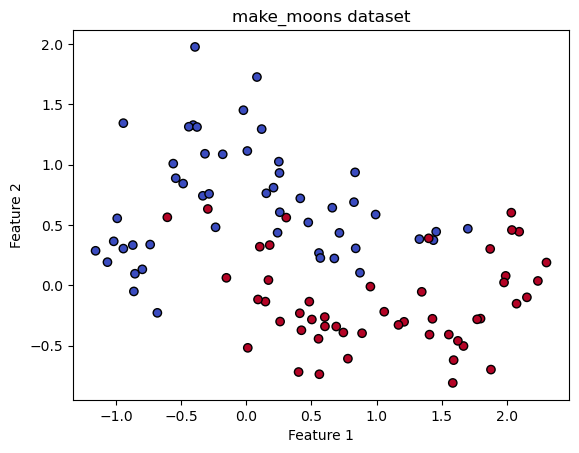

In [ ]:
#Testing 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
X, y = make_moons(noise=0.25, random_state=69)
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_moons dataset")
plt.show()

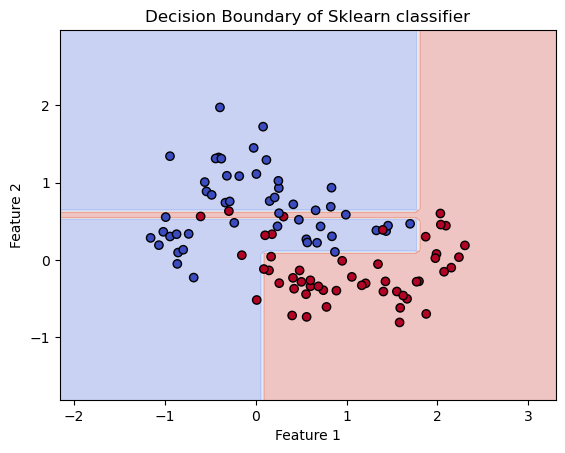

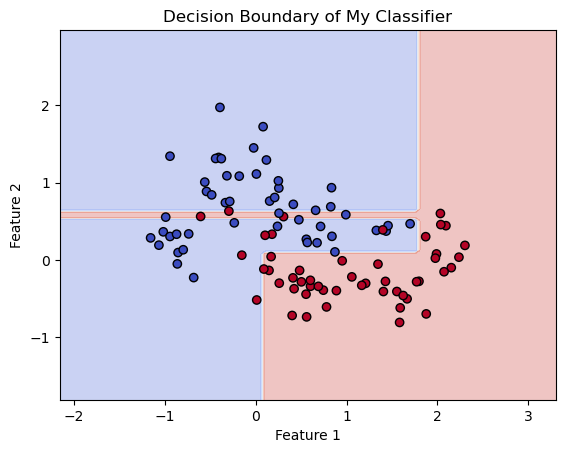

In [ ]:
number = 4
sklearn_classifier = DecisionTreeClassifier(splitter="best", min_samples_leaf=number)
sklearn_classifier.fit(X, y)

my_classifier = DecisionTree(min_samples_leaf=number)
my_classifier.fit(X,y)


display1 = DecisionBoundaryDisplay.from_estimator(
    sklearn_classifier,
    X,
    response_method="predict",
    xlabel="Feature 1",
    ylabel="Feature 2",
    alpha=0.3,  
    cmap=plt.cm.coolwarm
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("Decision Boundary of Sklearn classifier")
plt.show()

display2 = DecisionBoundaryDisplay.from_estimator(
    my_classifier,
    X,
    response_method="predict",
    xlabel="Feature 1",
    ylabel="Feature 2",
    alpha=0.3,  
    cmap=plt.cm.coolwarm
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("Decision Boundary of My Classifier")
plt.show()




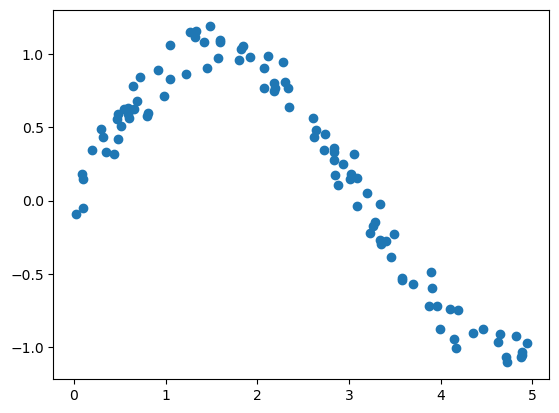

True

In [10]:
# from sklearn.datasets import load_diabetes

# X, y = load_diabetes(return_X_y=True)

rng = np.random.RandomState(0)
X = np.sort(5 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.1 * rng.randn(100)
plt.scatter(X, y)
plt.show()
from sklearn.tree import DecisionTreeRegressor

sk = DecisionTreeRegressor(max_depth=4)
my = DecisionTree(max_depth=4)

sk.fit(X, y)
my.fit(X,y)

np.allclose(
    sk.predict(X),
    my.predict(X),
    atol=1e-6
)